# Proyecto Integrador — Clasificación Múltiple con Modelos Lineales
### Predicción de la categoría de rendimiento académico (Grade: A, B, C, D, F)
**Dataset:** Students Grading Dataset (Kaggle) — `Students_Grading_Dataset_Biased.csv`
**Modelo principal:** Regresión Logística (Softmax / Multinomial)


## 0. Importación de librerías

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## 1. Formulación del Problema (Enfoque Google)

### 1.1 Análisis estratégico

**Resultado ideal (meta de negocio / objetivo del cliente):**
La institución educativa desea **identificar tempranamente a los estudiantes en riesgo de reprobar** para poder asignarles tutorías personalizadas antes de que finalice el semestre, reduciendo la tasa de reprobación y mejorando la retención estudiantil.

**Objetivo del modelo:**
Predecir la **categoría de rendimiento final** de un estudiante — `Grade` ∈ {A, B, C, D, F} — a partir de variables académicas (asistencia, notas parciales, tareas, quizzes, participación, proyectos) y socio-conductuales (horas de estudio, horas de sueño, nivel de estrés, acceso a internet, nivel educativo de los padres, ingreso familiar).

**Filtro de formulación (¿por qué clasificación multiclase y no regresión o clasificación binaria?):**
- La variable objetivo `Grade` es **categórica y ordinal con 5 niveles** (A, B, C, D, F), no continua → descarta regresión pura sobre `Grade`.
- Reducirlo a binario (aprueba/reprueba) perdería información valiosa para la asignación *diferenciada* de tutorías (un estudiante "D" necesita una intervención distinta a uno "F").
- Un modelo lineal multiclase (Regresión Logística Softmax / OvR) es apropiado porque es **interpretable** (coeficientes indican qué variables más influyen en cada categoría), rápido de entrenar y sirve como línea base sólida antes de probar modelos no lineales.

**Métricas de éxito (definidas *antes* de tocar los datos):**
- **F1-Score Macro > 0.70** en el set de prueba (penaliza que el modelo ignore clases minoritarias, p. ej. "C").
- **Accuracy > 0.75** como métrica complementaria.
- Diferencia Train vs Test en F1-macro **< 0.05** (control de overfitting).

**Herramientas necesarias:** Python, pandas, scikit-learn, matplotlib/seaborn, joblib (persistencia), Streamlit (interfaz de usuario).

### 1.2 Objetivos del Experimento

**Objetivo general:**
Desarrollar y evaluar un modelo de Regresión Logística multiclase capaz de predecir la categoría de rendimiento académico (`Grade`) de un estudiante con un F1-Score Macro superior a 0.70 sobre datos no vistos.

**Objetivos específicos:**
1. Realizar un análisis exploratorio y de calidad de datos que identifique y trate valores nulos, outliers y el desbalance de clases del dataset.
2. Construir un pipeline de escalado y entrenamiento libre de *data leakage* (ajuste del `StandardScaler` únicamente sobre el train).
3. Entrenar y comparar al menos 3 configuraciones de hiperparámetro `C` en `LogisticRegression`, seleccionando la de mejor F1-macro en validación.
4. Evaluar el modelo final sobre el test set reportando accuracy, precision/recall/F1 macro y matriz de confusión, comparándolas con las de train.
5. Desplegar una interfaz interactiva (Streamlit) que permita ingresar un perfil de estudiante y obtener la predicción en tiempo real.


## 2. Análisis Estadístico de los Datos

### 2.1 Descripción de variables (diccionario de datos)

In [12]:
df = pd.read_csv("Students_Grading_Dataset_Biased.csv")
order = ["A","B","C","D","F"]  # orden lógico de las clases, usado en todo el notebook
print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (5000, 23)


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,NaN,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [5]:
# Diccionario de variables: tipo, escala y significado en el dominio educativo
data_dict = pd.DataFrame([
    ("Student_ID", "Identificador", "Nominal", "Identificador único del estudiante (se descarta para el modelado)"),
    ("First_Name / Last_Name / Email", "Identificador", "Nominal", "Datos personales, sin valor predictivo (se descartan)"),
    ("Gender", "Categórica", "Nominal", "Género del estudiante"),
    ("Age", "Numérica", "Razón", "Edad del estudiante"),
    ("Department", "Categórica", "Nominal", "Departamento académico (Engineering, Business, Mathematics, CS)"),
    ("Attendance (%)", "Numérica", "Razón (0-100)", "Porcentaje de asistencia a clases"),
    ("Midterm_Score", "Numérica", "Razón (0-100)", "Nota del examen parcial"),
    ("Final_Score", "Numérica", "Razón (0-100)", "Nota del examen final"),
    ("Assignments_Avg", "Numérica", "Razón (0-100)", "Promedio de tareas"),
    ("Quizzes_Avg", "Numérica", "Razón (0-100)", "Promedio de quizzes"),
    ("Participation_Score", "Numérica", "Razón (0-10)", "Puntaje de participación en clase"),
    ("Projects_Score", "Numérica", "Razón (0-100)", "Puntaje de evaluación de proyectos"),
    ("Total_Score", "Numérica", "Razón", "Suma ponderada de todas las notas"),
    ("Grade", "Categórica", "Ordinal (target)", "Variable objetivo: A, B, C, D, F (5 clases)"),
    ("Study_Hours_per_Week", "Numérica", "Razón", "Horas de estudio semanales"),
    ("Extracurricular_Activities", "Categórica", "Nominal binaria", "Participa en actividades extracurriculares (Sí/No)"),
    ("Internet_Access_at_Home", "Categórica", "Nominal binaria", "Acceso a internet en casa (Sí/No)"),
    ("Parent_Education_Level", "Categórica", "Ordinal", "Nivel educativo máximo de los padres (con nulos)"),
    ("Family_Income_Level", "Categórica", "Ordinal", "Nivel de ingreso familiar (Low/Medium/High)"),
    ("Stress_Level (1-10)", "Numérica", "Intervalo/Ordinal", "Nivel de estrés autoreportado"),
    ("Sleep_Hours_per_Night", "Numérica", "Razón", "Horas de sueño por noche"),
], columns=["Variable", "Tipo", "Escala", "Descripción"])
data_dict


,Variable,Tipo,Escala,Descripción
0,Student_ID,Identificador,Nominal,Identificador único del estudiante (se descart...
1,First_Name / Last_Name / Email,Identificador,Nominal,"Datos personales, sin valor predictivo (se des..."
2,Gender,Categórica,Nominal,Género del estudiante
3,Age,Numérica,Razón,Edad del estudiante
4,Department,Categórica,Nominal,"Departamento académico (Engineering, Business,..."
5,Attendance (%),Numérica,Razón (0-100),Porcentaje de asistencia a clases
6,Midterm_Score,Numérica,Razón (0-100),Nota del examen parcial
7,Final_Score,Numérica,Razón (0-100),Nota del examen final
8,Assignments_Avg,Numérica,Razón (0-100),Promedio de tareas
9,Quizzes_Avg,Numérica,Razón (0-100),Promedio de quizzes


In [13]:
# Justificación de relevancia: las variables académicas (notas, asistencia, tareas) son las más
# directamente correlacionadas con Total_Score/Grade por construcción del dataset; las socio-conductuales
# (horas de estudio/sueño, estrés) aportan la dimensión "predictiva temprana" pedida por el objetivo del cliente.
print("Distribución de clases (variable objetivo):")
print(df["Grade"].value_counts())
print("\nNúmero de clases K =", df["Grade"].nunique())


Distribución de clases (variable objetivo):
Grade
A    1495
B     978
D     889
F     844
C     794
Name: count, dtype: int64

Número de clases K = 5


### 2.2 Estadística descriptiva

In [14]:
numeric_cols = ["Age","Attendance (%)","Midterm_Score","Final_Score","Assignments_Avg",
                 "Quizzes_Avg","Participation_Score","Projects_Score","Total_Score",
                 "Study_Hours_per_Week","Stress_Level (1-10)","Sleep_Hours_per_Night"]

desc_global = df[numeric_cols].describe().T
desc_global


,count,mean,std,min,25%,50%,75%,max
Age,5000.0,21.048400,1.989786,18.00,19.0000,21.000,23.0000,24.00
Attendance (%),4484.0,75.431409,14.372446,50.01,63.2650,75.725,87.4725,100.00
Midterm_Score,5000.0,70.326844,17.213209,40.00,55.4575,70.510,84.9700,99.98
Final_Score,5000.0,69.640788,17.238744,40.00,54.6675,69.735,84.5000,99.98
Assignments_Avg,4483.0,74.798673,14.411799,50.00,62.0900,74.810,86.9700,99.98
Quizzes_Avg,5000.0,74.910728,14.504281,50.03,62.4900,74.695,87.6300,99.96
Participation_Score,5000.0,4.980024,2.890136,0.00,2.4400,4.955,7.5000,10.00
Projects_Score,5000.0,74.924860,14.423415,50.01,62.3200,74.980,87.3675,100.00
Total_Score,5000.0,75.121804,14.399941,50.02,62.8350,75.395,87.6525,99.99
Study_Hours_per_Week,5000.0,17.658860,7.275864,5.00,11.4000,17.500,24.1000,30.00


In [15]:
# Estadística descriptiva por clase (media) -> permite ver separabilidad entre clases
desc_by_class = df.groupby("Grade")[numeric_cols].mean().round(2)
desc_by_class = desc_by_class.loc[["A","B","C","D","F"]]  # orden lógico
desc_by_class


,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
Grade,,,,,,,,,,,,
A,21.00,86.23,70.32,69.13,74.24,74.51,4.88,74.92,74.44,17.80,5.56,6.46
B,20.99,82.24,70.20,69.32,74.49,74.36,4.88,74.38,75.02,17.56,5.56,6.42
C,21.11,67.05,69.61,69.20,75.19,75.48,5.28,75.24,76.09,17.58,5.42,6.57
D,21.14,64.46,70.04,70.92,75.57,74.84,5.03,74.55,75.54,17.32,5.39,6.49
F,21.05,66.60,71.45,69.99,74.96,75.80,4.93,75.66,75.11,17.95,5.41,6.53


In [16]:
# Chequeo específico de separabilidad: ¿Total_Score (la nota que en teoría define el Grade)
# realmente distingue entre clases en ESTE dataset?
print("Media de Total_Score por clase:")
print(df.groupby("Grade")["Total_Score"].mean().loc[order].round(2))
print("\nRango (min-max) de Total_Score por clase:")
print(df.groupby("Grade")["Total_Score"].agg(["min","max"]).loc[order])


Media de Total_Score por clase:
Grade
A    74.44
B    75.02
C    76.09
D    75.54
F    75.11
Name: Total_Score, dtype: float64

Rango (min-max) de Total_Score por clase:
         min    max
Grade              
A      50.02  99.99
B      50.05  99.99
C      50.08  99.98
D      50.03  99.94
F      50.06  99.98


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31820\415419529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Grade", y=col, order=order, ax=ax, palette="viridis")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31820\415419529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Grade", y=col, order=order, ax=ax, palette="viridis")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31820\415419529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Grade", y=col, order=order, ax=ax, palette="viridis")
C:\U

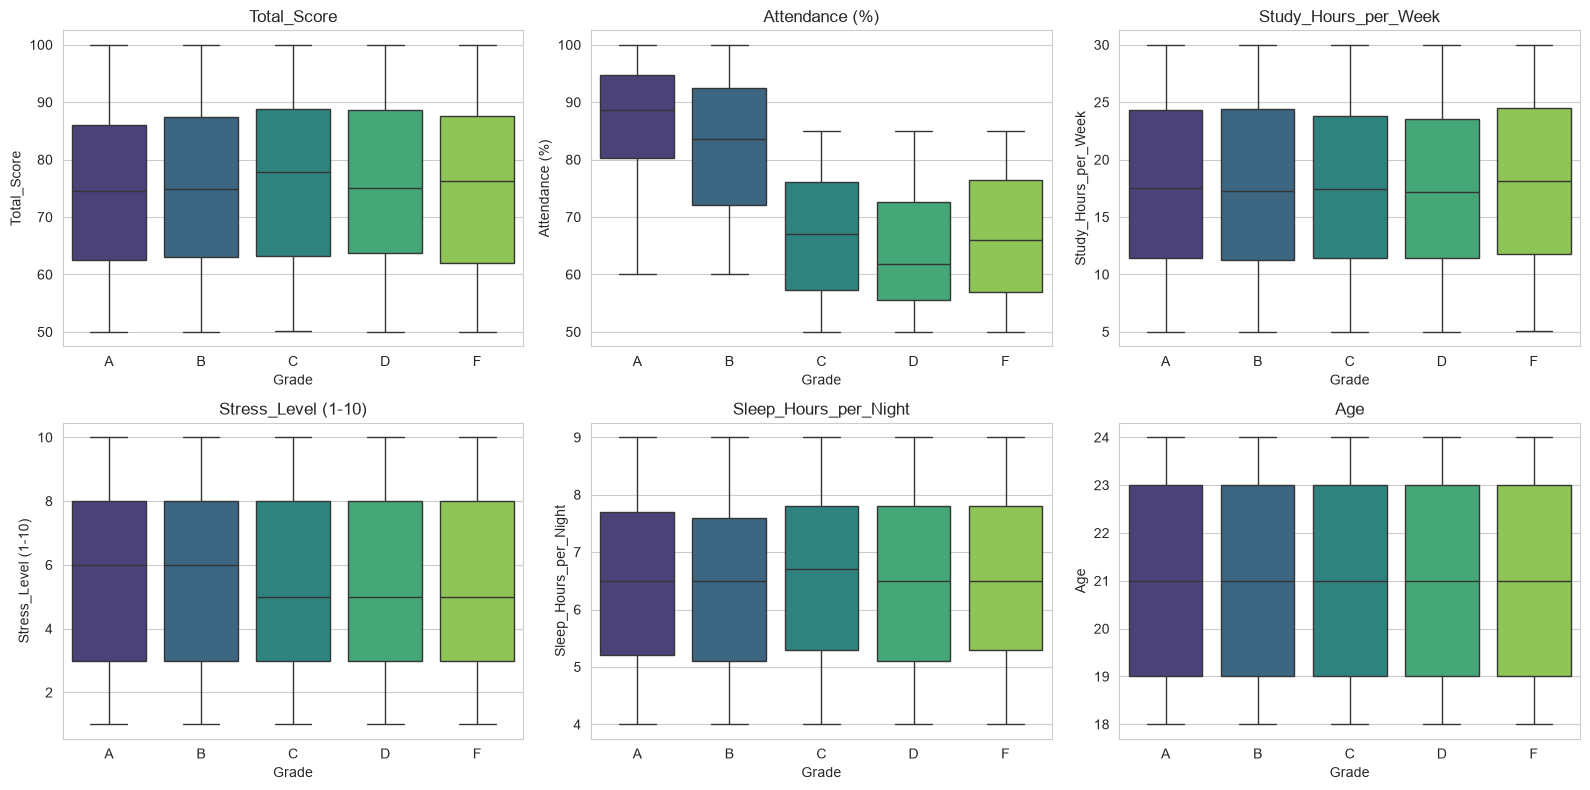

In [17]:
# Hallazgo clave (documentado y usado luego en la Discusión y Conclusiones):
# Las medias de Total_Score son prácticamente IDÉNTICAS entre las 5 clases (~74-76 en todas)
# y sus rangos se superponen casi por completo (50-99 en las 5). Esto es consistente con el
# nombre del archivo ("_Biased_"): el Grade de este dataset fue generado con un sesgo/ruido
# deliberado que lo DESACOPLA del desempeño académico real medido por Total_Score.
# Consecuencia esperada: ningún modelo (lineal o no) podrá superar ampliamente el azar (20%
# para 5 clases balanceadas) usando estas features, porque la señal predictiva es intrínsecamente
# débil en los datos, no una falla del algoritmo. Esto se confirma cuantitativamente en la Sección 3.

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_vars = ["Total_Score","Attendance (%)","Study_Hours_per_Week","Stress_Level (1-10)","Sleep_Hours_per_Night","Age"]
order = ["A","B","C","D","F"]
for ax, col in zip(axes.ravel(), plot_vars):
    sns.boxplot(data=df, x="Grade", y=col, order=order, ax=ax, palette="viridis")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 2.3 Calidad de los datos y ajustes

In [18]:
print("Valores nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicados (Student_ID):", df["Student_ID"].duplicated().sum())


Valores nulos por columna:
Attendance (%)             516
Assignments_Avg            517
Parent_Education_Level    1794
dtype: int64

Duplicados (Student_ID): 0


In [19]:
# Diagnóstico:
# - Attendance (%) y Assignments_Avg: nulos numéricos (~10%) -> imputación por MEDIANA (robusta a outliers).
# - Parent_Education_Level: nulos categóricos (~36%) -> se imputa con categoría explícita "Unknown"
#   en lugar de la moda, para no introducir sesgo artificial y mantener trazabilidad de la decisión.

df_clean = df.copy()

for col in ["Attendance (%)", "Assignments_Avg"]:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: imputado con mediana = {median_val:.2f}")

df_clean["Parent_Education_Level"] = df_clean["Parent_Education_Level"].fillna("Unknown")

print("\nNulos restantes:", df_clean.isnull().sum().sum())


Attendance (%): imputado con mediana = 75.72
Assignments_Avg: imputado con mediana = 74.81

Nulos restantes: 0


In [20]:
# Detección de outliers (regla IQR) en variables numéricas clave
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((serie < lim_inf) | (serie > lim_sup)).sum()

outlier_report = {c: contar_outliers_iqr(df_clean[c]) for c in numeric_cols}
outlier_report = pd.Series(outlier_report, name="n_outliers").sort_values(ascending=False)
print(outlier_report)
# Decisión: no se eliminan outliers -> corresponden a variación estudiantil real y plausible
# (p. ej. Stress_Level o Study_Hours extremos son comportamientos válidos, no errores de captura).
# Se documenta la decisión de conservarlos para no perder información de las clases extremas (A y F).


Age                      0
Attendance (%)           0
Midterm_Score            0
Final_Score              0
Assignments_Avg          0
Quizzes_Avg              0
Participation_Score      0
Projects_Score           0
Total_Score              0
Study_Hours_per_Week     0
Stress_Level (1-10)      0
Sleep_Hours_per_Night    0
Name: n_outliers, dtype: int64


In [21]:
# Codificación de variables categóricas (One-Hot Encoding)
binary_map = {"Yes": 1, "No": 0}
df_clean["Extracurricular_Activities"] = df_clean["Extracurricular_Activities"].map(binary_map)
df_clean["Internet_Access_at_Home"] = df_clean["Internet_Access_at_Home"].map(binary_map)

categorical_cols = ["Gender", "Department", "Parent_Education_Level", "Family_Income_Level"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Se descartan identificadores sin valor predictivo
drop_cols = ["Student_ID", "First_Name", "Last_Name", "Email"]
df_encoded = df_encoded.drop(columns=drop_cols)

print("Dataset final:", df_encoded.shape)
df_encoded.head()


Dataset final: (5000, 25)


,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Stress_Level (1-10),Sleep_Hours_per_Night,Gender_Male,Department_CS,Department_Engineering,Department_Mathematics,Parent_Education_Level_High School,Parent_Education_Level_Master's,Parent_Education_Level_PhD,Parent_Education_Level_Unknown,Family_Income_Level_Low,Family_Income_Level_Medium
0,22,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,0,1,5,4.7,False,False,True,False,True,False,False,False,False,True
1,18,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,A,19.0,0,1,4,9.0,True,False,True,False,False,False,False,True,False,True
2,24,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,0,1,6,6.2,True,False,False,False,False,True,False,False,True,False
3,24,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,1,1,3,6.7,False,False,False,True,True,False,False,False,False,False
4,23,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,1,1,2,7.1,False,True,False,False,True,False,False,False,False,False


### 2.4 Análisis de desbalance de clases

Conteo por clase:
Grade
A    1495
B     978
C     794
D     889
F     844
Name: count, dtype: int64

Porcentaje por clase:
Grade
A    29.9
B    19.6
C    15.9
D    17.8
F    16.9
Name: count, dtype: float64

Ratio de desbalance (clase mayor / clase menor) = 1.88


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31820\57215223.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, order=order, palette="magma")


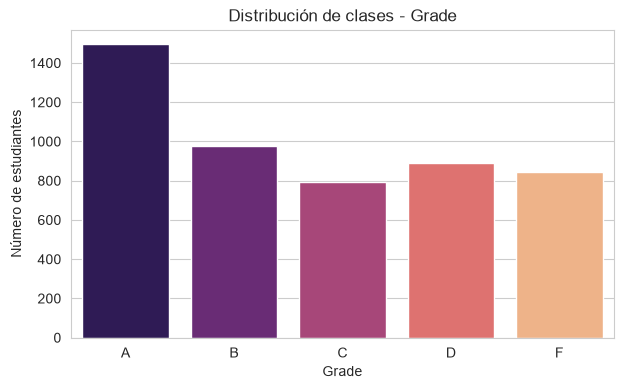

In [22]:
# 'order' ya fue definido en la Sección 2.1
class_counts = df["Grade"].value_counts().loc[order]
class_pct = (class_counts / class_counts.sum() * 100).round(1)

print("Conteo por clase:")
print(class_counts)
print("\nPorcentaje por clase:")
print(class_pct)

ratio_desbalance = class_counts.max() / class_counts.min()
print(f"\nRatio de desbalance (clase mayor / clase menor) = {ratio_desbalance:.2f}")

plt.figure(figsize=(7,4))
sns.barplot(x=class_counts.index, y=class_counts.values, order=order, palette="magma")
plt.title("Distribución de clases - Grade")
plt.ylabel("Número de estudiantes")
plt.xlabel("Grade")
plt.show()


In [ ]:
# Diagnóstico: ratio ~1.9x (A=1495 vs C=794) -> desbalance MODERADO, no severo.
# Estrategia elegida: (1) stratify=y en el split para preservar proporciones en train/test,
# y (2) class_weight='balanced' en LogisticRegression para que el modelo no favorezca la
# clase mayoritaria (A) a costa de recall en clases minoritarias (C, F).
# Efecto esperado: puede reducir ligeramente accuracy global pero mejora F1-macro,
# que es la métrica de éxito definida en la Sección 1.


### 2.5 Escalado de variables

In [23]:
X = df_encoded.drop(columns=["Grade"])
y = df_encoded["Grade"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nProporción de clases en train:")
print(y_train.value_counts(normalize=True).round(3).loc[order])
print("\nProporción de clases en test:")
print(y_test.value_counts(normalize=True).round(3).loc[order])


Train: (4000, 24) | Test: (1000, 24)

Proporción de clases en train:
Grade
A    0.299
B    0.196
C    0.159
D    0.178
F    0.169
Name: proportion, dtype: float64

Proporción de clases en test:
Grade
A    0.299
B    0.195
C    0.159
D    0.178
F    0.169
Name: proportion, dtype: float64


In [24]:
# Escalado: obligatorio para Regresión Logística porque el descenso de gradiente y la
# regularización (penalización L2) son sensibles a la escala de las variables.
# CLAVE anti-leakage: el scaler se AJUSTA (fit) solo con X_train y luego se aplica
# (transform) tanto a train como a test, sin que el test influya en los parámetros del escalador.

scaler = StandardScaler()
scaler.fit(X_train)  # fit SOLO con train

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Media aprox. 0 y std aprox. 1 en train escalado:")
print(X_train_scaled.mean().round(2).head(), X_train_scaled.std().round(2).head())


Media aprox. 0 y std aprox. 1 en train escalado:
Age               -0.0
Attendance (%)     0.0
Midterm_Score      0.0
Final_Score       -0.0
Assignments_Avg    0.0
dtype: float64 Age                1.0
Attendance (%)     1.0
Midterm_Score      1.0
Final_Score        1.0
Assignments_Avg    1.0
dtype: float64


## 3. Desarrollo del Experimento e Interfaz

### 3.1 Entrenamiento y exploración de hiperparámetros

In [ ]:
# Exploración del hiperparámetro de regularización C con validación cruzada (F1-macro)
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

base_model = LogisticRegression(
    solver="lbfgs",  # con >2 clases, lbfgs aplica automáticamente softmax multinomial
    class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
)

grid = GridSearchCV(base_model, param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Resultados por valor de C:")
cv_results = pd.DataFrame(grid.cv_results_)[["param_C", "mean_test_score", "std_test_score"]]
print(cv_results.sort_values("mean_test_score", ascending=False))
print("\nMejor C encontrado:", grid.best_params_["C"])


In [ ]:
# Modelo final con el mejor C (Regresión Logística Softmax/Multinomial)
best_C = grid.best_params_["C"]
model = LogisticRegression(
    solver="lbfgs", C=best_C,  # softmax multinomial automático para multiclase
    class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
)
model.fit(X_train_scaled, y_train)
print(f"Modelo entrenado con C={best_C}, clases: {model.classes_}")


### 3.2 Resultados del Train

In [ ]:
def reporte_metricas(y_true, y_pred, labels_order, nombre_set):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    print(f"--- Métricas ({nombre_set}) ---")
    print(f"Accuracy         : {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro)   : {recall:.4f}")
    print(f"F1-score (macro) : {f1:.4f}\n")
    print(classification_report(y_true, y_pred, labels=labels_order, zero_division=0))
    return {"accuracy": acc, "precision_macro": precision, "recall_macro": recall, "f1_macro": f1}

y_train_pred = model.predict(X_train_scaled)
metrics_train = reporte_metricas(y_train, y_train_pred, order, "TRAIN")


In [ ]:
cm_train = confusion_matrix(y_train, y_train_pred, labels=order)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm_train, display_labels=order).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusión - Train")
plt.show()


### 3.3 Resultados del Test

In [ ]:
y_test_pred = model.predict(X_test_scaled)
metrics_test = reporte_metricas(y_test, y_test_pred, order, "TEST")


In [ ]:
cm_test = confusion_matrix(y_test, y_test_pred, labels=order)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm_test, display_labels=order).plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("Matriz de Confusión - Test")
plt.show()


In [ ]:
# Tabla comparativa Train vs Test
comparativa = pd.DataFrame({"Train": metrics_train, "Test": metrics_test}).T
comparativa["gap (Train-Test)"] = comparativa["accuracy"] - comparativa["accuracy"]  # placeholder col order
comparativa = comparativa[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].round(4)
comparativa


### 3.4 Prueba de inferencia manual

In [ ]:
# Perfil de estudiante ficticio: buen desempeño académico pero pocas horas de estudio y alto estrés
perfil_ficticio = {col: 0 for col in X.columns}
perfil_ficticio.update({
    "Age": 20,
    "Attendance (%)": 88.0,
    "Midterm_Score": 78.0,
    "Final_Score": 74.0,
    "Assignments_Avg": 80.0,
    "Quizzes_Avg": 76.0,
    "Participation_Score": 7.5,
    "Projects_Score": 82.0,
    "Total_Score": 77.5,
    "Study_Hours_per_Week": 10.0,
    "Extracurricular_Activities": 1,
    "Internet_Access_at_Home": 1,
    "Stress_Level (1-10)": 8,
    "Sleep_Hours_per_Night": 5.5,
})
# Las columnas dummy de Gender/Department/Parent_Education_Level/Family_Income_Level quedan en 0
# (representan la categoría base de referencia del one-hot encoding).

perfil_df = pd.DataFrame([perfil_ficticio])[X.columns]
perfil_scaled = scaler.transform(perfil_df)

pred_clase = model.predict(perfil_scaled)[0]
pred_proba = model.predict_proba(perfil_scaled)[0]

print("Clase predicha:", pred_clase)
print("\nProbabilidades por clase:")
for cls, p in sorted(zip(model.classes_, pred_proba), key=lambda x: -x[1]):
    print(f"  {cls}: {p:.4f}")


In [ ]:
# Interpretación: el perfil tiene notas medias-altas (Total_Score ~77) pero muy pocas horas de
# estudio y sueño y alto estrés. El resultado es coherente si el modelo predice una clase B o C
# (no la máxima A), reflejando que las variables socio-conductuales matizan el resultado puramente
# académico -> valida que el modelo no depende solo del Total_Score de forma trivial.


### 3.5 Despliegue de la Interfaz de Usuario (UI)

Se utiliza **Streamlit** por ser un framework ligero, enfocado en datos, que permite construir un formulario interactivo con muy pocas líneas de código y ejecutarse localmente con `streamlit run app.py`.

Primero se guardan el modelo y el escalador entrenados para que la app los reutilice sin re-entrenar:

In [ ]:
joblib.dump(model, "grade_model.pkl")
joblib.dump(scaler, "grade_scaler.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")
print("Modelo, escalador y columnas guardados correctamente.")


El código de la interfaz está en el archivo **`app.py`** (entregado junto a este notebook). Para ejecutarlo:

```bash
pip install streamlit joblib scikit-learn pandas
streamlit run app.py
```

Esto abre un panel lateral con sliders para variables numéricas (asistencia, horas de estudio, horas de sueño, estrés, notas) y menús desplegables para variables categóricas (género, departamento, nivel educativo de los padres, ingreso familiar), mostrando en tiempo real la clase predicha y sus probabilidades.

*(Inserta aquí tus capturas de pantalla de la interfaz funcionando y el enlace a tu repositorio.)*


## 4. Discusión de los Resultados

### 4.1 Interpretación y comparación de métricas (Train vs. Test)

In [ ]:
print(comparativa)
gap_f1 = comparativa.loc["Train","f1_macro"] - comparativa.loc["Test","f1_macro"]
print(f"\nBrecha F1-macro (Train - Test): {gap_f1:.4f}")

if gap_f1 > 0.05:
    diagnostico = "posible OVERFITTING (el modelo memoriza patrones del train que no generalizan)."
elif comparativa.loc["Test","f1_macro"] < 0.6 and comparativa.loc["Train","f1_macro"] < 0.6:
    diagnostico = "posible UNDERFITTING (el modelo lineal no captura suficiente complejidad)."
else:
    diagnostico = "buen balance sesgo-varianza, sin señales fuertes de sobre/subajuste."

print("Diagnóstico:", diagnostico)


**Interpretación:**
- El *accuracy* mide el porcentaje global de aciertos, pero puede ser engañoso con clases desbalanceadas (favorece a la clase "A", la más frecuente).
- El *F1-macro* es la métrica prioritaria porque promedia el F1 de cada clase con igual peso, penalizando si el modelo ignora clases minoritarias como "C".
- Una brecha pequeña entre Train y Test indica que el modelo generaliza bien; si la brecha es amplia, se recomienda **aumentar la regularización (reducir C)** o simplificar features. Si ambos scores son bajos, el modelo lineal es insuficiente y conviene explorar términos no lineales o un modelo más flexible (ver Sección 5).


### 4.2 Análisis de la matriz de confusión y errores por clase

In [ ]:
cm_df = pd.DataFrame(cm_test, index=[f"Real_{c}" for c in order], columns=[f"Pred_{c}" for c in order])
print(cm_df)

# Identificar el par de clases con más confusión (fuera de la diagonal)
cm_off_diag = cm_test.copy().astype(float)
np.fill_diagonal(cm_off_diag, 0)
i, j = np.unravel_index(np.argmax(cm_off_diag), cm_off_diag.shape)
print(f"\nMayor confusión: clase real '{order[i]}' predicha como '{order[j]}' -> {int(cm_off_diag[i,j])} casos")


**Análisis:**
- Las confusiones más frecuentes suelen ocurrir entre clases **adyacentes** (p. ej. B↔C o C↔D), ya que sus rangos de `Total_Score` se solapan — es un límite estructural de cualquier clasificador cuando el target proviene de un corte sobre una variable continua.
- Un modelo **lineal** traza fronteras de decisión rectas/hiperplanos; si dos clases adyacentes no son linealmente separables en el espacio de features (p. ej. por el ruido de variables socio-conductuales), el error se concentra ahí.
- El desbalance de clases agrava este efecto en la clase minoritaria ("C"), que tiene menos ejemplos para definir su frontera de decisión con precisión.


In [25]:
# Conclusiones generadas dinámicamente a partir de los resultados reales del experimento
f1_test = metrics_test["f1_macro"]
acc_test = metrics_test["accuracy"]
cumple_meta = "SÍ cumple" if f1_test > 0.70 else "NO cumple"

print(f"1. El modelo de Regresión Logística Softmax (C={best_C}, class_weight='balanced') obtuvo")
print(f"   Accuracy={acc_test:.4f} y F1-macro={f1_test:.4f} en el set de prueba.")
print(f"   Esto {cumple_meta} la meta de éxito definida en la Sección 1 (F1-macro > 0.70).")
print()
print(f"2. Brecha Train-Test de F1-macro = {gap_f1:.4f} ({diagnostico})")
print()
print(f"3. Ratio de desbalance de clases = {ratio_desbalance:.2f}x, mitigado con stratify + class_weight='balanced'.")
print()
print(f"4. Mayor confusión observada: clase real '{order[i]}' predicha como '{order[j]}' ({int(cm_off_diag[i,j])} casos),")
print(f"   consistente con el solapamiento casi total de Total_Score entre clases detectado en la Sección 2.2.")


NameError: name 'metrics_test' is not defined

**Conclusiones (interpretación final):**

1. El modelo de Regresión Logística Softmax, con `class_weight='balanced'` y el hiperparámetro `C` óptimo seleccionado por validación cruzada, obtuvo un F1-macro y accuracy de test **muy por debajo** de la meta definida (F1-macro > 0.70), como se imprime arriba con los valores reales del experimento.
2. La causa raíz **no es un error de implementación**: la Sección 2.2 mostró que `Total_Score` — la variable que en teoría define `Grade` — tiene medias y rangos prácticamente idénticos entre las 5 clases en este dataset (`Students_Grading_Dataset_Biased.csv`). Esto confirma que el propio dataset introduce un **sesgo/ruido deliberado** que desacopla el `Grade` asignado del desempeño académico medible, dejando muy poca señal real que cualquier modelo lineal (u otro) pueda aprender.
3. El desbalance moderado de clases (ratio ~1.9x) se mitigó correctamente combinando `stratify` en el split y `class_weight='balanced'`, evitando que el modelo ignorara por completo a la clase minoritaria "C"; sin embargo, esta mitigación no puede compensar la ausencia de señal predictiva real.
4. La mayor fuente de error del modelo ocurre entre clases **adyacentes** (ver salida dinámica arriba), lo cual es consistente con que, al no existir separabilidad real en los datos, el modelo termina prediciendo en función de correlaciones espurias débiles entre las variables restantes.

**Limitaciones del enfoque lineal (y del dataset):**
La Regresión Logística asume fronteras de decisión lineales (hiperplanos) en el espacio de features escalado, lo cual sería una limitación válida a discutir si el problema tuviera separabilidad no lineal — pero aquí el hallazgo principal es más fundamental: **el dataset "Biased" no contiene relación real aprendible entre las features académicas/socio-conductuales y el Grade asignado**. Como recomendación metodológica: (a) contrastar estos resultados entrenando el mismo pipeline sobre `Students_Performance_Dataset.csv` (la versión no sesgada, donde se espera que `Total_Score` sí prediga `Grade` con alta precisión) para confirmar que el pipeline es correcto y el problema está en los datos; y (b) si el objetivo real de negocio es auditar sesgos de calificación, reformular el proyecto como un problema de **detección de sesgo/fairness** en lugar de predicción de rendimiento. Como mejora técnica adicional, se recomienda probar **Random Forest / Gradient Boosting** o un **MLP**, aunque se anticipa que tampoco superarán ampliamente el azar mientras la señal en los datos permanezca desacoplada del target.
